In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
df = pd.read_csv("D:\CA_251090050530\ipl_full_matches.csv")



In [ ]:
print("First 10 Records:")
print(df.head(10))

First 10 Records:
   id  season         city        date team1 team2 toss_winner toss_decision  \
0   1    2008      Chepauk  2008-04-01    GT   SRH          GT           bat   
1   2    2008     Wankhede  2008-04-02   KKR  PBKS        PBKS           bat   
2   3    2008      Chepauk  2008-04-03  PBKS    RR        PBKS           bat   
3   4    2008  Chinnaswamy  2008-04-04   RCB    MI          MI           bat   
4   5    2008     Narendra  2008-04-05   KKR  PBKS        PBKS           bat   
5   6    2008        Rajiv  2008-04-06   KKR   RCB         KKR           bat   
6   7    2008     Narendra  2008-04-07    GT    RR          RR           bat   
7   8    2008      Chepauk  2008-04-08   LSG    MI         LSG         field   
8   9    2008         Arun  2008-04-09  PBKS   SRH        PBKS           bat   
9  10    2008     Wankhede  2008-04-10    GT  PBKS        PBKS           bat   

  winner                  venue  result  result_margin player_of_match  
0    SRH        Chepauk Stad

In [ ]:
# Total Matches
if 'id' in df.columns:
    total_matches = df['id'].nunique()
else:
    total_matches = len(df)

# Extract Teams
if 'team1' in df.columns and 'team2' in df.columns:
    all_teams = pd.concat([df['team1'], df['team2']]).unique()
    total_teams = len(all_teams)
else:
    total_teams = "Check column names"

print("\nTotal Matches:", total_matches)
print("Total Teams:", total_teams)
print("Total Seasons:", total_seasons)



Total Matches: 560
Total Teams: 10
Total Seasons: 16


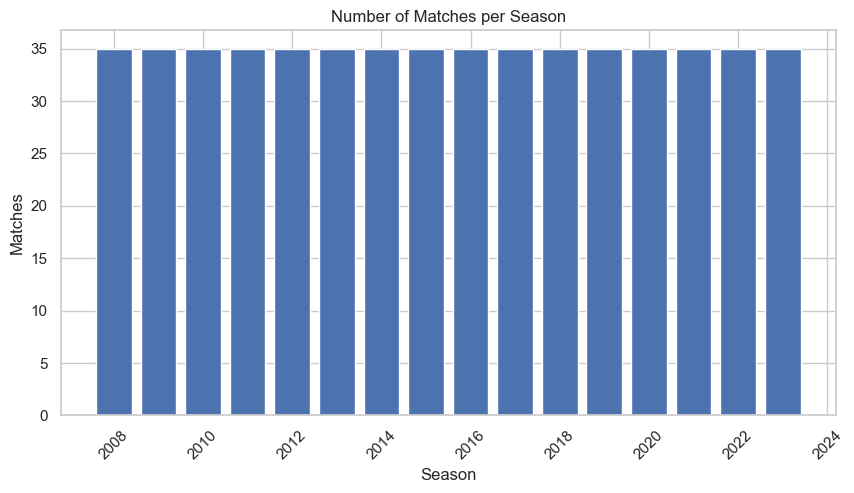

In [ ]:
matches_per_season = df.groupby('season').size()

plt.figure(figsize=(10,5))
plt.bar(matches_per_season.index, matches_per_season.values)
plt.title("Number of Matches per Season")
plt.xlabel("Season")
plt.ylabel("Matches")
plt.xticks(rotation=45)
plt.show()

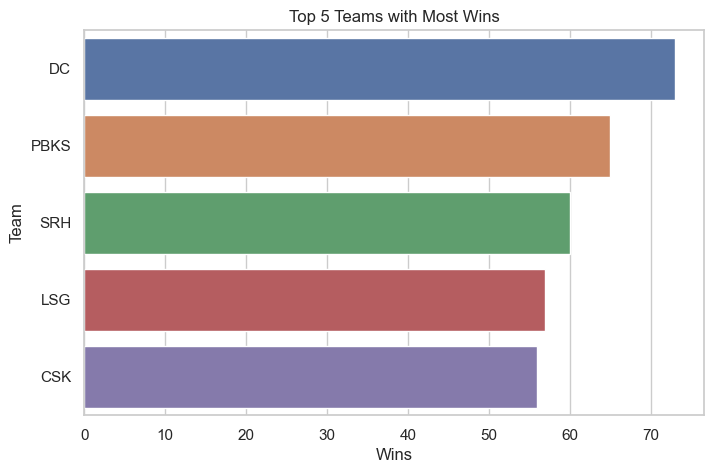

In [ ]:
if 'winner' in df.columns:
    top_teams = df['winner'].value_counts().head(5)

    plt.figure(figsize=(8,5))
    sns.barplot(x=top_teams.values, y=top_teams.index)
    plt.title("Top 5 Teams with Most Wins")
    plt.xlabel("Wins")
    plt.ylabel("Team")
    plt.show()

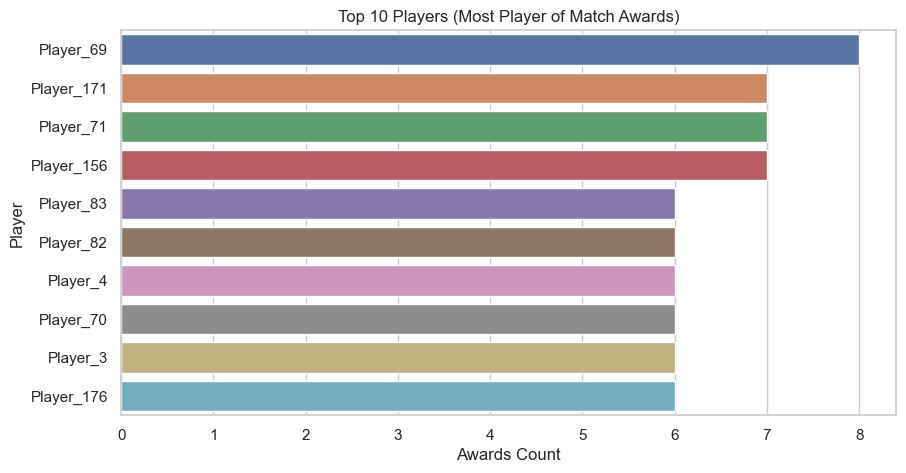

In [ ]:
if 'player_of_match' in df.columns:
    top_players = df['player_of_match'].value_counts().head(10)

    plt.figure(figsize=(10,5))
    sns.barplot(x=top_players.values, y=top_players.index)
    plt.title("Top 10 Players (Most Player of Match Awards)")
    plt.xlabel("Awards Count")
    plt.ylabel("Player")
    plt.show()

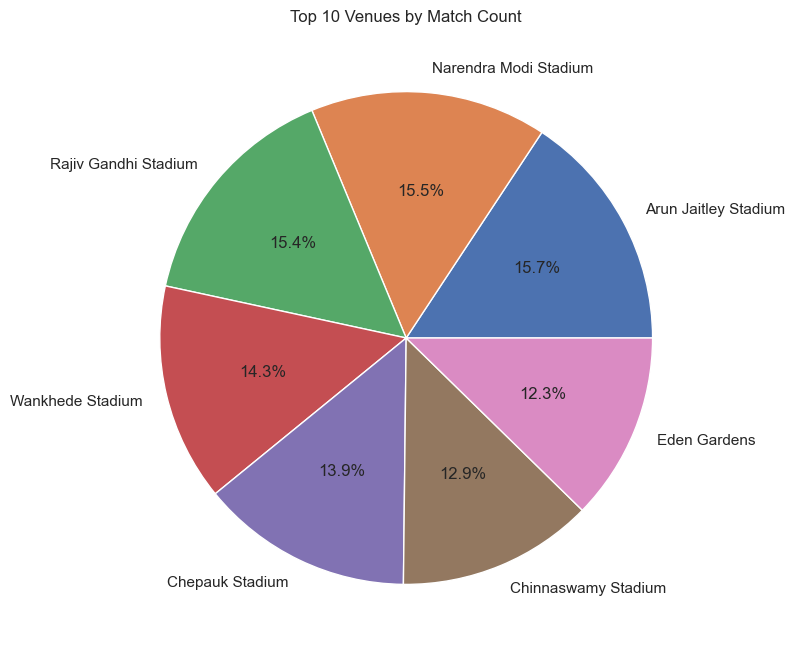

In [ ]:
if 'venue' in df.columns:
    wins_by_venue = df['venue'].value_counts().head(10)

    plt.figure(figsize=(8,8))
    plt.pie(wins_by_venue.values,
            labels=wins_by_venue.index,
            autopct='%1.1f%%')
    plt.title("Top 10 Venues by Match Count")
    plt.show()

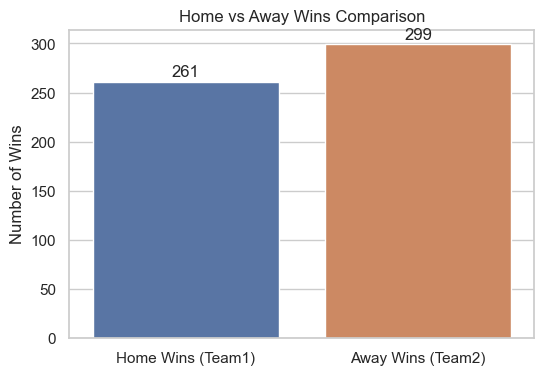

In [ ]:

if 'team1' in df.columns and 'team2' in df.columns and 'winner' in df.columns:

    home_wins = (df['winner'] == df['team1']).sum()

    away_wins = (df['winner'] == df['team2']).sum()

    plt.figure(figsize=(6,4))
    sns.barplot(x=["Home Wins (Team1)", "Away Wins (Team2)"],
                y=[home_wins, away_wins])
    plt.title("Home vs Away Wins Comparison")
    plt.ylabel("Number of Wins")
    plt.text(0, home_wins + 5, home_wins, ha='center')
    plt.text(1, away_wins + 5, away_wins, ha='center')
    plt.show()

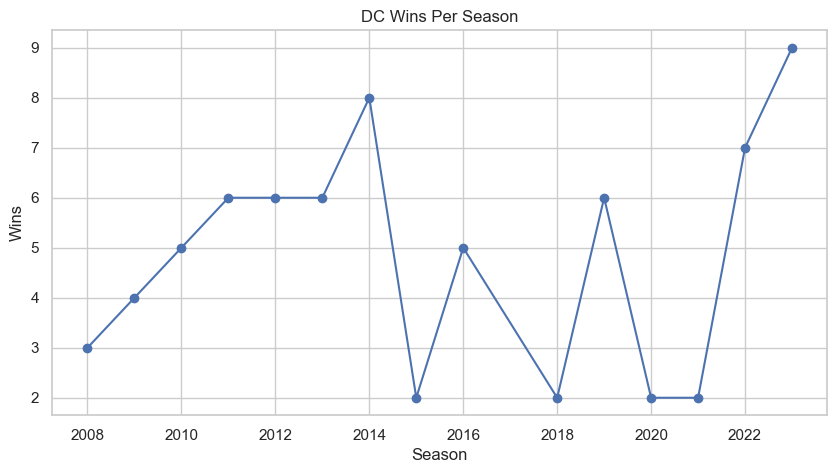

In [ ]:
if 'winner' in df.columns:

    team_name = df['winner'].value_counts().index[0]  # most winning team
    team_data = df[df['winner'] == team_name]
    team_per_season = team_data.groupby('season').size()

    plt.figure(figsize=(10,5))
    plt.plot(team_per_season.index,
             team_per_season.values,
             marker='o')
    plt.title(f"{team_name} Wins Per Season")
    plt.xlabel("Season")
    plt.ylabel("Wins")
    plt.grid(True)
    plt.show()

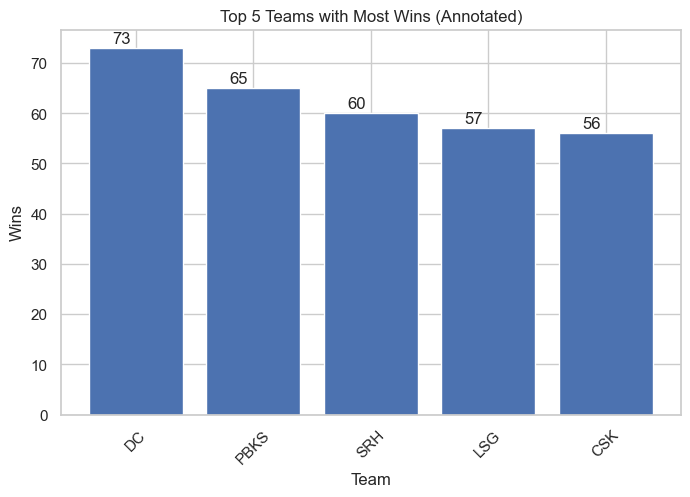

In [ ]:
if 'winner' in df.columns:
    plt.figure(figsize=(8,5))
    bars = plt.bar(top_teams.index, top_teams.values)

    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + 0.2, yval + 1, yval)

    plt.title("Top 5 Teams with Most Wins (Annotated)")
    plt.xlabel("Team")
    plt.ylabel("Wins")
    plt.xticks(rotation=45)
    plt.show()
